In [97]:
import torch
import pandas as pandas
import numpy as np
import matplotlib.pyplot as plt

print(torch.__version__)


2.13.0+cpu


## Introduction to tensor

Creating Tensors

In [98]:
# scalar

scalar = torch.tensor(7)
scalar

tensor(7)

In [99]:
scalar.ndim

0

In [100]:
# get tensor back as python int
scalar.item()

7

In [101]:
# Vector
vector = torch.tensor([7, 7])
vector

tensor([7, 7])

In [102]:
vector.ndim

1

In [103]:
vector.shape

torch.Size([2])

In [104]:
# Matrix

MATRIX = torch.tensor([[5, 6], [9, 10]])
MATRIX

tensor([[ 5,  6],
        [ 9, 10]])

In [105]:
MATRIX.ndim

2

In [106]:
MATRIX[1]

tensor([ 9, 10])

In [107]:
MATRIX.shape

torch.Size([2, 2])

In [108]:
# TENSORS
TENSOR = torch.tensor([[[1, 2, 3], [3, 6, 9], [2, 4, 5]]])
TENSOR

tensor([[[1, 2, 3],
         [3, 6, 9],
         [2, 4, 5]]])

In [109]:
TENSOR.ndim

3

In [110]:
TENSOR.shape  # one three by three tensor

torch.Size([1, 3, 3])

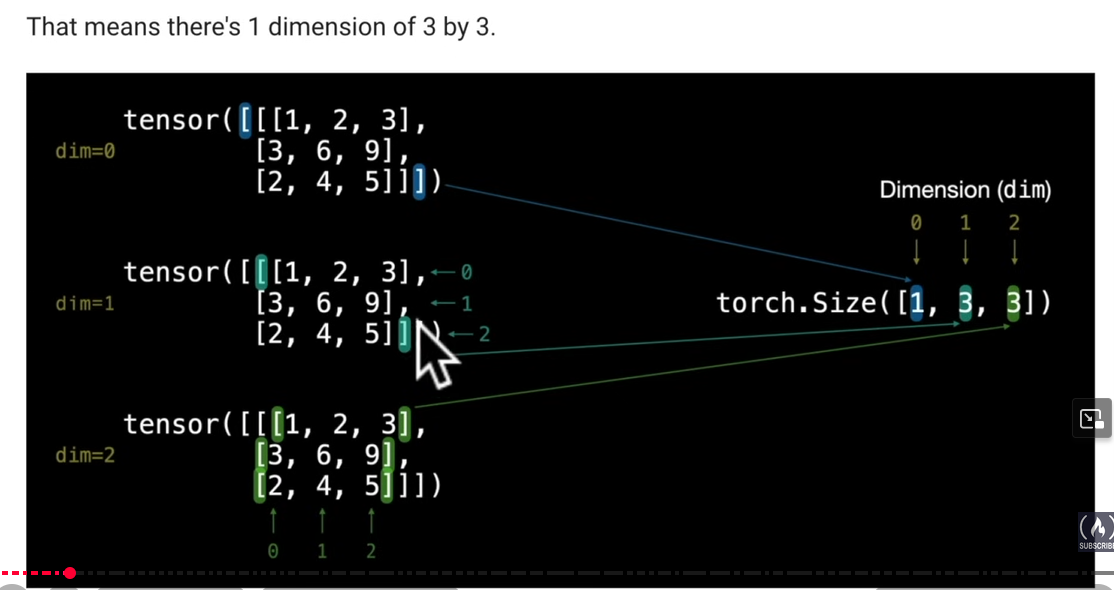

In [111]:
TENSOR[0]

tensor([[1, 2, 3],
        [3, 6, 9],
        [2, 4, 5]])

In [112]:
TENSOR1 = torch.tensor([[[1, 2, 3, 4, 5], [2, 3, 4, 11, 2], [12, 3, 43, 12, 32]]])

TENSOR1.shape

torch.Size([1, 3, 5])

## Random Tensors

why random tensors?

- random tensors are importat because the way manu Neural networks learn is that they start with tensors full of random numbers and then adjust those random numbers to better represent the data

starts with random number ---> look at data ----> update random numbers ---> look at data ---> update random numbers

In [113]:
# Create a random tensor of size(3,4)

random_tensor = torch.rand(3, 4)
random_tensor

tensor([[0.8860, 0.5832, 0.3376, 0.8090],
        [0.5779, 0.9040, 0.5547, 0.3423],
        [0.6343, 0.3644, 0.7104, 0.9464]])

In [114]:
random_tensor.ndim

2

In [115]:
# Create a random tensor with similar shape to image tensor
random_image_size_tensor = torch.rand(
    size=(3, 224, 224)
)  # height ,width , color channels(R,G,B)
random_image_size_tensor.shape, random_image_size_tensor.ndim


(torch.Size([3, 224, 224]), 3)

### Zeros and one 

In [116]:
# Create a tensor with all zeros

zeros = torch.zeros(size=(3, 4))
zeros

tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])

In [117]:
zeros * random_tensor

tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])

In [118]:
# Create a tensor of all ones
ones = torch.ones(size=(3, 4))
ones

tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]])

In [119]:
ones.dtype

torch.float32

In [120]:
random_tensor.dtype

torch.float32

### Creating a range of tensors and tensors-like

In [121]:
# use torch.range() and get deprecated message,use torch.arange()

one_to_ten = torch.arange(start=1, end=11, step=1)
one_to_ten

tensor([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10])

In [122]:
# creating tensors like

ten_zeros = torch.zeros_like(input=one_to_ten)
ten_zeros

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

# Tensor datatypes

Tensor datatypes is one of the 3 big errors youll run into with pytorch and DL-

1) Tensor not right datatype
2) Tensor not right shape
3) Tensors not on the right device

In [123]:
# Float32 tensor
float_32_tensor = torch.tensor([3.0,6.0,9.0],
                               dtype = None,  #What datatype is the tensor (float16 or float32)
                               device = None,  #what device is your tensor on
                               requires_grad=False) #Whether or not to track gradients with this tensor operation
float_32_tensor


tensor([3., 6., 9.])

In [124]:
float_16_tensor = float_32_tensor.type(torch.float16)
float_16_tensor

tensor([3., 6., 9.], dtype=torch.float16)

In [125]:
float_16_tensor * float_32_tensor

tensor([ 9., 36., 81.])

In [126]:
int_32_tensor = torch.tensor([3,6,9],dtype=torch.long)
int_32_tensor

tensor([3, 6, 9])

In [127]:
float_32_tensor * int_32_tensor
 

tensor([ 9., 36., 81.])

### Getting Informations from tensor
1) Tensor not right datatype - to get datatype from tensor we can use tensor.dtype
2) Tensor not right shape - to get shape from tensor we can use tensor.shape
3) Tensors not on the right device - to get device from tensor we can use tensor.device

In [128]:
# Create a tensor
some_tensor = torch.rand(3, 4)
some_tensor

# Find out details about some tensor
print(some_tensor)
print(f"Datatype of tensor: {some_tensor.dtype}")
print(f"Shape of tensor: {some_tensor.shape}")
print(f"Device tensor is on: {some_tensor.device}")

tensor([[0.3968, 0.1496, 0.4743, 0.9973],
        [0.4436, 0.9726, 0.5194, 0.5337],
        [0.7050, 0.3362, 0.7891, 0.1694]])
Datatype of tensor: torch.float32
Shape of tensor: torch.Size([3, 4])
Device tensor is on: cpu


## Manipulating Tensors

Tensor operations include- 
- Addition
- Substraction
- Multiplication
- Division
- Matrix multiplication

In [129]:
#create a tensor

tensor = torch.tensor([1,2,3])
tensor + 10

tensor([11, 12, 13])

In [130]:
tensor * 10

tensor([10, 20, 30])

In [131]:
#try out pytorch in built funstions
torch.mul(tensor,10)

tensor([10, 20, 30])

In [132]:
torch.add(tensor,20)

tensor([21, 22, 23])

### Matrix multiplication

two main ways of performing multiplication in neural networks and deep learning

1) Element wise multiplication 
2) Matrix Multiplication

There are two main rules that performing matrix multiplication has to satisfy-
1) The **inner dimensions must match:
2) resulting matrix has the shape of outer dimesnions


In [133]:
#Element wise multiplication

print(tensor ,"x", tensor)
print("Equals: ",tensor*tensor)


tensor([1, 2, 3]) x tensor([1, 2, 3])
Equals:  tensor([1, 4, 9])


In [134]:
#Matrix Multiplication
torch.matmul(tensor,tensor)

tensor(14)

In [135]:
%%time

value = 0

for i in range(len(tensor)):
    value += tensor[i] * tensor[i]

print(value)

tensor(14)
CPU times: total: 0 ns
Wall time: 5 ms


In [136]:
%%time

torch.matmul(tensor,tensor)

CPU times: total: 0 ns
Wall time: 1.01 ms


tensor(14)

### One of the most common error in deep learning

Shape Errors

In [137]:
#shapes for matrix multiplication

# Shapes for matrix multiplication
tensor_A = torch.tensor([[1, 2],
                         [3, 4],
                         [5, 6]])

tensor_B = torch.tensor([[7, 10],
                         [8, 11],
                         [9, 12]])

# torch.mm(tensor_A, tensor_B) # torch.mm is the same as torch.matmul
#torch.matmul(tensor_A, tensor_B) wont work

In [138]:
tensor_A.shape, tensor_B.shape

(torch.Size([3, 2]), torch.Size([3, 2]))

To fix our tensor shape issues, we can manipulate the shape of one of our tensors using a **transpose**.

A **transpose** switches the axes or dimensions of a given tensor.

In [139]:
tensor_B.T

tensor([[ 7,  8,  9],
        [10, 11, 12]])

In [140]:
# The matrix multiplication operation works when tensor_B is transposed
print(f"Original shapes: tensor_A = {tensor_A.shape}, tensor_B = {tensor_B.shape}")
print(f"New shapes: tensor_A = {tensor_A.shape} (same shape as above), tensor_B.T = {tensor_B.T.shape}")
print(f"Multiplying: {tensor_A.shape} @ {tensor_B.T.shape} <- inner dimensions must match")
print("Output:\n")

output = torch.matmul(tensor_A, tensor_B.T)
print(output)
print(f"\nOutput shape: {output.shape}")

Original shapes: tensor_A = torch.Size([3, 2]), tensor_B = torch.Size([3, 2])
New shapes: tensor_A = torch.Size([3, 2]) (same shape as above), tensor_B.T = torch.Size([2, 3])
Multiplying: torch.Size([3, 2]) @ torch.Size([2, 3]) <- inner dimensions must match
Output:

tensor([[ 27,  30,  33],
        [ 61,  68,  75],
        [ 95, 106, 117]])

Output shape: torch.Size([3, 3])


### Finding the min max sum etc(tensor aggregation)

In [141]:
#Create a tensor
x = torch.arange(0,100,10)
x , x.dtype

(tensor([ 0, 10, 20, 30, 40, 50, 60, 70, 80, 90]), torch.int64)

In [142]:
#Find the min
torch.min(x) , x.min()

(tensor(0), tensor(0))

In [143]:
#Find the max
torch.max(x) , x.max()

(tensor(90), tensor(90))

In [144]:
#Find the mean
torch.mean(x.type(torch.float32)), x.type(torch.float32).mean()


(tensor(45.), tensor(45.))

In [145]:
#Find the sum
torch.sum(x) , x.sum()

(tensor(450), tensor(450))

### Find the positional min and max

In [146]:
x

tensor([ 0, 10, 20, 30, 40, 50, 60, 70, 80, 90])

In [147]:
x.argmin()# find the position in tensor that has minimum value, return index

tensor(0)

In [148]:
x[0]

tensor(0)

In [149]:
#find the position in tensor that has maximum value with argmax()

x.argmax()

tensor(9)

In [150]:
x[9]

tensor(90)

### Reshaping , stackinng , squeezing and unsqueezing tensors

* Reshaping - reshapes a input tensor to a defined shape

* View - Return a view of an input tensor of a certain shape but keep the same memory as the original tensor

* Staacking - Stacking multiple tensors on top of each other or side by side

* Squeeze - removes all one dimension from a tensor

* Unsqueeze - add 1 dimension to the target tensor

* Permute - Return a view of the input with dimensions permuted in a certain way

In [151]:
#Lets create a tensor

import torch
x=torch.arange(1.,11.)
x , x.shape

(tensor([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.]), torch.Size([10]))

In [152]:
# Add an extra Dimension

x_reshaped = x.reshape(5,2)
x_reshaped , x_reshaped.shape

(tensor([[ 1.,  2.],
         [ 3.,  4.],
         [ 5.,  6.],
         [ 7.,  8.],
         [ 9., 10.]]),
 torch.Size([5, 2]))

In [153]:
#change the view

z = x.view(2,5)
z,z.shape

(tensor([[ 1.,  2.,  3.,  4.,  5.],
         [ 6.,  7.,  8.,  9., 10.]]),
 torch.Size([2, 5]))

In [154]:
#changing z changes x because view of the tensor shares the same memory as the original

#z[:,0] = 5
#z,x

In [155]:
#stacks tensors on top of each other

x_stacked = torch.stack([x,x,x,x])
x_stacked

tensor([[ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.],
        [ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.],
        [ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.],
        [ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.]])

In [156]:
#torch.squeeze - removes all single dimensions from a target tensorx = torch.zeros(2, 1, 2, 1, 2)
x = torch.zeros(2, 1, 2, 1, 2)
print(x.size())

y = torch.squeeze(x)
print(y.size())

y = torch.squeeze(x, 0)
print(y.size())

y = torch.squeeze(x, 1)
print(y.size())

torch.Size([2, 1, 2, 1, 2])
torch.Size([2, 2, 2])
torch.Size([2, 1, 2, 1, 2])
torch.Size([2, 2, 1, 2])


In [157]:
# torch.squeeze() - removes all single dimensions from a target tensor

x = torch.tensor([[5., 2., 3., 4., 5., 6., 7., 8., 9.]])

print(f"Previous tensor: {x}")
print(f"Previous shape: {x.shape}")

# Remove extra dimensions from x
x_squeezed = x.squeeze()

print(f"\nNew tensor: {x_squeezed}")
print(f"New shape: {x_squeezed.shape}")

Previous tensor: tensor([[5., 2., 3., 4., 5., 6., 7., 8., 9.]])
Previous shape: torch.Size([1, 9])

New tensor: tensor([5., 2., 3., 4., 5., 6., 7., 8., 9.])
New shape: torch.Size([9])


In [158]:
# torch.unsqueeze() - adds a single dimension to a target tensor at a specific dim (dimension)
print(f"Previous target: {x_squeezed}")
print(f"Previous shape: {x_squeezed.shape}")

# Add an extra dimension with unsqueeze
x_unsqueezed = x_squeezed.unsqueeze(dim=1)
print(f"\nNew tensor: {x_unsqueezed}")
print(f"New shape: {x_unsqueezed.shape}")

Previous target: tensor([5., 2., 3., 4., 5., 6., 7., 8., 9.])
Previous shape: torch.Size([9])

New tensor: tensor([[5.],
        [2.],
        [3.],
        [4.],
        [5.],
        [6.],
        [7.],
        [8.],
        [9.]])
New shape: torch.Size([9, 1])


In [159]:
# torch.permute - rearranges the dimensions of a target tensor in a specified order
x_original = torch.rand(size=(224, 224, 3)) # [height, width, colour_channels]

# Permute the original tensor to rearrange the axis (or dim) order
x_permuted = x_original.permute(2, 0, 1) # shifts axis 0->1, 1->2, 2->0

print(f"Previous shape: {x_original.shape}")
print(f"New shape: {x_permuted.shape}")#color channel , height , width

Previous shape: torch.Size([224, 224, 3])
New shape: torch.Size([3, 224, 224])


In [160]:
x_original[0,0,0] = 3012
x_original

tensor([[[3.0120e+03, 7.1769e-01, 6.9877e-01],
         [5.5098e-01, 2.4852e-01, 8.5176e-01],
         [9.6260e-02, 1.3377e-01, 2.7409e-01],
         ...,
         [9.3452e-01, 9.4241e-01, 8.5544e-01],
         [6.7049e-01, 8.6584e-01, 9.8256e-01],
         [4.2009e-01, 7.8628e-01, 7.3982e-01]],

        [[6.7003e-01, 6.4436e-01, 1.2922e-01],
         [1.2167e-01, 5.5278e-01, 4.9640e-01],
         [9.2416e-01, 8.0686e-03, 1.4173e-01],
         ...,
         [3.3819e-01, 4.5696e-01, 9.1838e-02],
         [4.5219e-01, 9.5509e-01, 4.3275e-01],
         [8.2453e-02, 1.4915e-01, 6.9136e-01]],

        [[5.8647e-01, 3.0766e-01, 3.3106e-01],
         [8.5141e-02, 3.7493e-01, 9.2261e-01],
         [7.3039e-01, 7.8551e-01, 4.1098e-01],
         ...,
         [7.4202e-02, 5.0273e-02, 9.6059e-01],
         [2.8235e-01, 7.6851e-01, 9.2919e-01],
         [1.7532e-01, 6.4167e-01, 3.9675e-01]],

        ...,

        [[3.7714e-01, 3.2223e-01, 3.3207e-01],
         [5.2228e-01, 6.6243e-01, 7.1378e-01]

### Indexing (selecting data from tensors)

Indexing with PyTorch is similar to indexing with NumPy.

In [161]:
 # Create a tensor
import torch
x = torch.arange(1, 10).reshape(1, 3, 3)
x, x.shape

(tensor([[[1, 2, 3],
          [4, 5, 6],
          [7, 8, 9]]]),
 torch.Size([1, 3, 3]))

In [162]:
x[0]

tensor([[1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]])

In [163]:
#Lets index on the middle bracket(dim = 1)
x[0][0]

tensor([1, 2, 3])

In [164]:
#Lets index on most inner bracket
x[0][0][0] , x[0][2][2]

(tensor(1), tensor(9))

In [165]:
x[:,0] , x[:,:,1] , x[:,1,1]

(tensor([[1, 2, 3]]), tensor([[2, 5, 8]]), tensor([5]))

### PyTorch tensors & NumPy

NumPy is a popular scientific Python numerical computing library.

And because of this, PyTorch has functionality to interact with it.

* Data in NumPy, want in PyTorch tensor -> `torch.from_numpy(ndarray)`
* PyTorch tensor -> NumPy -> `torch.Tensor.numpy()`

In [166]:
array = np.arange(1.0,8.0)
tensor = torch.from_numpy(array) #Float64 numpy
array, tensor

(array([1., 2., 3., 4., 5., 6., 7.]),
 tensor([1., 2., 3., 4., 5., 6., 7.], dtype=torch.float64))

In [167]:
array = array +1
array , tensor

(array([2., 3., 4., 5., 6., 7., 8.]),
 tensor([1., 2., 3., 4., 5., 6., 7.], dtype=torch.float64))

In [168]:
#tensor to numpy array

tensor = torch.ones(7)
numpy_tensor = tensor.numpy()
tensor, numpy_tensor

(tensor([1., 1., 1., 1., 1., 1., 1.]),
 array([1., 1., 1., 1., 1., 1., 1.], dtype=float32))

In [169]:
#Change the tensor, what happens to numpy_tensor?

tensor = tensor + 1
tensor , numpy_tensor

(tensor([2., 2., 2., 2., 2., 2., 2.]),
 array([1., 1., 1., 1., 1., 1., 1.], dtype=float32))

### Reproducibility (trying to take random out of random)

how NN works-

start with random numbers -> tensor operations ->  update random numbers to try and make them better  representations of the data -> again -> again

to reduce the randomness in nn and pytorch , the is a concept of random seed

falvour the randomness

In [170]:
# Create two random tensors
random_tensor_A = torch.rand(3, 4)
random_tensor_B = torch.rand(3, 4)

print(random_tensor_A)
print(random_tensor_B)
print(random_tensor_A == random_tensor_B)

tensor([[0.3386, 0.3708, 0.0831, 0.0944],
        [0.6568, 0.7708, 0.1053, 0.1467],
        [0.1932, 0.9118, 0.1488, 0.0913]])
tensor([[0.4470, 0.2440, 0.5571, 0.1928],
        [0.0602, 0.5837, 0.0009, 0.7581],
        [0.5817, 0.4338, 0.0333, 0.3746]])
tensor([[False, False, False, False],
        [False, False, False, False],
        [False, False, False, False]])


In [171]:
# Set the random seed
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
random_tensor_C = torch.rand(3, 4)

torch.manual_seed(RANDOM_SEED)
random_tensor_D = torch.rand(3, 4)

print(random_tensor_C)
print(random_tensor_D)
print(random_tensor_C == random_tensor_D)

tensor([[0.8823, 0.9150, 0.3829, 0.9593],
        [0.3904, 0.6009, 0.2566, 0.7936],
        [0.9408, 0.1332, 0.9346, 0.5936]])
tensor([[0.8823, 0.9150, 0.3829, 0.9593],
        [0.3904, 0.6009, 0.2566, 0.7936],
        [0.9408, 0.1332, 0.9346, 0.5936]])
tensor([[True, True, True, True],
        [True, True, True, True],
        [True, True, True, True]])


In [172]:
torch.cuda.is_available()
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [173]:
torch.cuda.device_count()

0

## Putting tensors and models in gpu
the reason we want our tenors in gpu for faster computations

In [174]:
# Create a tensor (default on the CPU)
tensor = torch.tensor([1, 2, 3])

# Tensor not on GPU
print(tensor, tensor.device)

tensor([1, 2, 3]) cpu


In [175]:
# Move tensor to GPU (if available)
tensor_on_gpu = tensor.to(device)
tensor_on_gpu

tensor([1, 2, 3])

### Moving tensors back to the CPU

In [176]:
# If tensor is on GPU, can't transform it to NumPy
tensor_on_gpu.numpy()

array([1, 2, 3])

In [177]:
# To fix the GPU tensor with NumPy issue, we can first set it to the CPU
tensor_back_on_cpu = tensor_on_gpu.cpu().numpy()
tensor_back_on_cpu

array([1, 2, 3])

In [178]:
tensor_on_gpu

tensor([1, 2, 3])

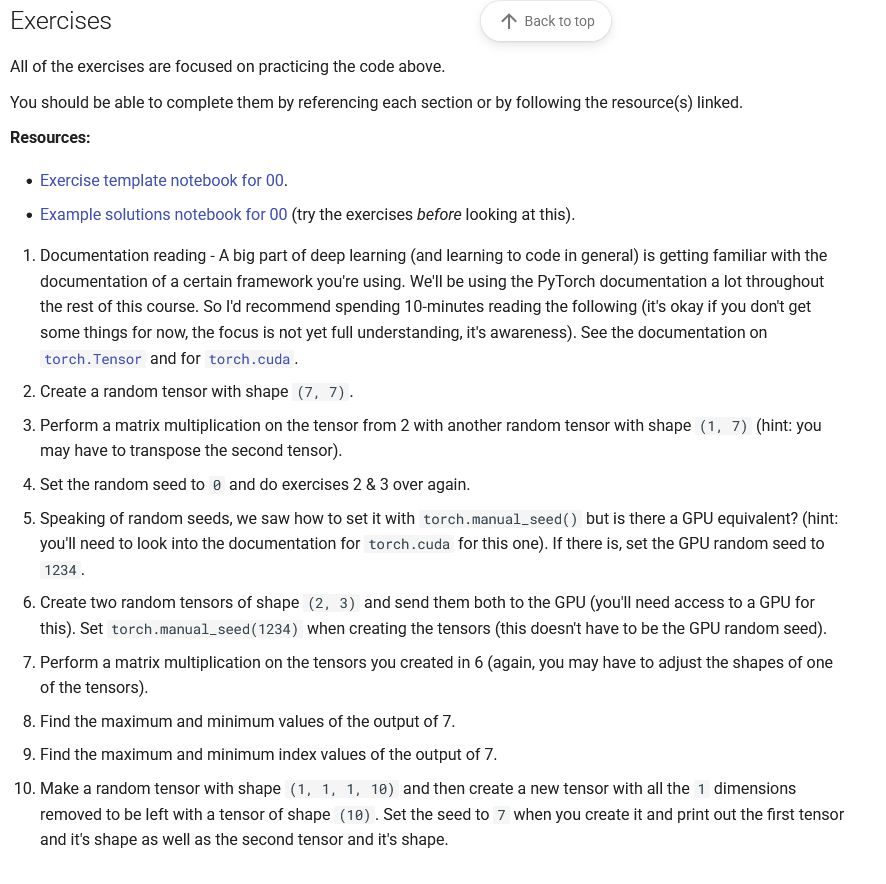

In [181]:
torch.manual_seed(7)
random_tensor = torch.rand(1,1,1,10)
random_tensor_2 = random_tensor.squeeze()
random_tensor_2.shape

torch.Size([10])

In [183]:
random_tensor , random_tensor_2 , random_tensor.shape , random_tensor_2.shape

(tensor([[[[0.5349, 0.1988, 0.6592, 0.6569, 0.2328, 0.4251, 0.2071, 0.6297,
            0.3653, 0.8513]]]]),
 tensor([0.5349, 0.1988, 0.6592, 0.6569, 0.2328, 0.4251, 0.2071, 0.6297, 0.3653,
         0.8513]),
 torch.Size([1, 1, 1, 10]),
 torch.Size([10]))